<a href="https://colab.research.google.com/github/mihirmaurya31/XAI-for-Phishing-URL-detection/blob/main/eda_phish.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Pre-processing Phase- Understanding the data basics!**

Url -- string (datatype object)

Label -- initially int64 for binary classification ( o or 1) but it can be Bool value as well (True or False)


Lexical count feature group -- int64 because it will be give quantity of no of dots, hyphen, @, &,_ and stuff.

Length features -- int64 because it will give the length of string
such as directory_length, file_length, params_length and stuff.

Network and Response feature group --  time_response is int64 but can be float64 as well because decimals can be possible as well.

qty_redirects -- int64 because it shows number of redirects.

http_status -- int64 shows status code 404,200.

server_header -- it can be object (string) as it is a categorical value.

tls_ssl_certificate -- is int64 initially but we need to check whether ssl certificate is present or not so it can be a bool value as well (True and False).





**Initial check how every column looks like**

In [2]:
import pandas as pd

#Read only a small sample to infer dtypes ----
sample_df = pd.read_csv("final_features_dataset.csv", nrows=None)

#Display column datatypes ----
print("=== COLUMN DATA TYPES ===")
#The output below shows the datatypes for all 115 columns
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(sample_df.dtypes)
print("\nTotal columns:", len(sample_df.columns))


#the first few rows ----
#print("\n=== FIRST 5 ROWS ===")
#print(sample_df.head())


=== COLUMN DATA TYPES ===
url                            object
Label                         float64
qty_dot_url                     int64
qty_hyphen_url                  int64
qty_underline_url               int64
qty_slash_url                   int64
qty_questionmark_url            int64
qty_equal_url                   int64
qty_at_url                      int64
qty_and_url                     int64
qty_exclamation_url             int64
qty_space_url                   int64
qty_tilde_url                   int64
qty_comma_url                   int64
qty_plus_url                    int64
qty_asterisk_url                int64
qty_hashtag_url                 int64
qty_dollar_url                  int64
qty_percent_url                 int64
length_url                    float64
qty_dot_domain                float64
qty_hyphen_domain             float64
qty_underline_domain          float64
qty_slash_domain              float64
qty_questionmark_domain       float64
qty_equal_domain        

In [3]:
print(sample_df['Label'].value_counts())


Label
1.0    39049
0.0       94
Name: count, dtype: int64


In [4]:
# Convert Label from float to boolean
sample_df['Label'] = sample_df['Label'].astype(bool)

# Verify the change
print(sample_df['Label'].dtype)
print(sample_df['Label'].value_counts())

bool
Label
True     39063
False       94
Name: count, dtype: int64


so we have 89.90% URls as Legitimate and 10.10% URls as phishing

In [5]:

import pandas as pd

# Load dataset (already bool)
sample_df = pd.read_csv("final_features_dataset.csv", low_memory=False)
sample_df['Label'] = sample_df['Label'].astype(bool)

# Count True/False
counts = sample_df['Label'].value_counts()
percentages = (counts / counts.sum()) * 100

# Display neatly
print("=== Label Distribution ===")
for label, count in counts.items():
    meaning = "Phishing" if label else "Legitimate"
    print(f"{meaning} ({label}): {count:,} URLs ({percentages[label]:.2f}%)")


=== Label Distribution ===
Phishing (True): 39,063 URLs (99.76%)
Legitimate (False): 94 URLs (0.24%)


In [6]:
import pandas as pd

#Load your dataset
samplesample0_df = pd.read_csv("final_features_dataset.csv", low_memory=False)

# List of columns to convert
cols_to_convert = [
    'qty_plus_params', 'qty_asterisk_params', 'qty_hashtag_params', 'qty_dollar_params',
    'qty_percent_params', 'params_length', 'qty_dot_fragment', 'qty_hyphen_fragment',
    'qty_underline_fragment', 'qty_slash_fragment', 'qty_questionmark_fragment',
    'qty_equal_fragment', 'qty_at_fragment', 'qty_and_fragment', 'qty_exclamation_fragment',
    'qty_space_fragment', 'qty_tilde_fragment', 'qty_comma_fragment', 'qty_plus_fragment',
    'qty_asterisk_fragment', 'qty_hashtag_fragment', 'qty_dollar_fragment',
    'qty_percent_fragment', 'fragment_length', 'time_response', 'qty_redirects','http_status', 'tls_ssl_certificate'
]

# Convert to int64 safely (handling NaN)
sample_df[cols_to_convert] = sample_df[cols_to_convert].fillna(0).astype('int64')

# Verify changes
print(sample_df[cols_to_convert].dtypes)


qty_plus_params              int64
qty_asterisk_params          int64
qty_hashtag_params           int64
qty_dollar_params            int64
qty_percent_params           int64
params_length                int64
qty_dot_fragment             int64
qty_hyphen_fragment          int64
qty_underline_fragment       int64
qty_slash_fragment           int64
qty_questionmark_fragment    int64
qty_equal_fragment           int64
qty_at_fragment              int64
qty_and_fragment             int64
qty_exclamation_fragment     int64
qty_space_fragment           int64
qty_tilde_fragment           int64
qty_comma_fragment           int64
qty_plus_fragment            int64
qty_asterisk_fragment        int64
qty_hashtag_fragment         int64
qty_dollar_fragment          int64
qty_percent_fragment         int64
fragment_length              int64
time_response                int64
qty_redirects                int64
http_status                  int64
tls_ssl_certificate          int64
dtype: object


In [7]:
print(sample_df.dtypes.value_counts())
print(sample_df['server_header'].value_counts())

float64    67
int64      45
object      2
bool        1
Name: count, dtype: int64
server_header
Apache                          1949
nginx                           1926
cloudflare                      1580
nginx + Phusion Passenger(R)     940
GSE                              749
                                ... 
nginx/1.10.1                       1
ELIN.hu                            1
WEB SERVER                         1
QRATOR                             1
openresty/1.25.3.1                 1
Name: count, Length: 254, dtype: int64


**Check missing values per column**

In [8]:
import pandas as pd

# Count missing values
missing_values = sample_df.isna().sum()

# Display
print(missing_values)

missing_report = (
    sample_df.isna().sum()
    .to_frame('Missing_Count')
    .assign(Missing_Percent=lambda x: (x['Missing_Count'] / len(sample_df)) * 100)
    .sort_values('Missing_Percent', ascending=False)
)

print("=== MISSING VALUE REPORT ===")
print(missing_report)



url                        0
Label                      0
qty_dot_url                0
qty_hyphen_url             0
qty_underline_url          0
                       ...  
time_response              0
qty_redirects              0
http_status                0
server_header          28164
tls_ssl_certificate        0
Length: 115, dtype: int64
=== MISSING VALUE REPORT ===
                      Missing_Count  Missing_Percent
server_header                 28164        71.925837
qty_percent_domain                1         0.002554
domain_length                     1         0.002554
qty_hashtag_domain                1         0.002554
qty_asterisk_domain               1         0.002554
...                             ...              ...
qty_percent_fragment              0         0.000000
time_response                     0         0.000000
qty_redirects                     0         0.000000
http_status                       0         0.000000
tls_ssl_certificate               0        

so we have Missing values in server_header and http_status
we can fix it using imputation method server_header datatype is object (Apache,Nginx) so we can impute Unknown. And in the server_header datatype is int64 datatype so we can impute (-1) basically it will show no response received from the URLs.

In [9]:
sample_df['server_header'] = sample_df['server_header'].fillna('Unknown')
sample_df['http_status'] = sample_df['http_status'].fillna(-1)
print(sample_df['http_status'].value_counts())
print(sample_df['server_header'].value_counts())

http_status
0      26616
404     6067
200     3526
405      922
403      814
500      305
504      209
520      114
410      112
503      100
400       87
406       75
444       65
429       25
502       21
401       18
416       13
526        9
530        7
202        6
522        6
204        5
521        5
412        4
418        4
409        4
307        4
501        4
525        2
999        2
556        1
415        1
302        1
423        1
422        1
509        1
Name: count, dtype: int64
server_header
Unknown                         28164
Apache                           1949
nginx                            1926
cloudflare                       1580
nginx + Phusion Passenger(R)      940
                                ...  
nginx/1.10.1                        1
ELIN.hu                             1
WEB SERVER                          1
QRATOR                              1
openresty/1.25.3.1                  1
Name: count, Length: 255, dtype: int64


**Fianl check for missing values**

In [10]:
import pandas as pd

# Assuming your DataFrame is named sample_df
missing_report = (
    sample_df.isna().sum()
    .to_frame('Missing_Count')
    .assign(Missing_Percent=lambda x: (x['Missing_Count'] / len(sample_df)) * 100)
    .sort_values('Missing_Percent', ascending=False)
)

print("=== MISSING VALUE REPORT ===")
print(missing_report)


=== MISSING VALUE REPORT ===
                     Missing_Count  Missing_Percent
domain_length                    1         0.002554
qty_percent_domain               1         0.002554
qty_dollar_domain                1         0.002554
qty_hashtag_domain               1         0.002554
qty_asterisk_domain              1         0.002554
...                            ...              ...
time_response                    0         0.000000
qty_redirects                    0         0.000000
http_status                      0         0.000000
server_header                    0         0.000000
tls_ssl_certificate              0         0.000000

[115 rows x 2 columns]


**Final look for the columns**

In [11]:
#Display column datatypes ----
print("=== COLUMN DATA TYPES ===")
#The output below shows the datatypes for all 115 columns
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(sample_df.dtypes)
print("\nTotal columns:", len(sample_df.columns))


=== COLUMN DATA TYPES ===
url                            object
Label                            bool
qty_dot_url                     int64
qty_hyphen_url                  int64
qty_underline_url               int64
qty_slash_url                   int64
qty_questionmark_url            int64
qty_equal_url                   int64
qty_at_url                      int64
qty_and_url                     int64
qty_exclamation_url             int64
qty_space_url                   int64
qty_tilde_url                   int64
qty_comma_url                   int64
qty_plus_url                    int64
qty_asterisk_url                int64
qty_hashtag_url                 int64
qty_dollar_url                  int64
qty_percent_url                 int64
length_url                    float64
qty_dot_domain                float64
qty_hyphen_domain             float64
qty_underline_domain          float64
qty_slash_domain              float64
qty_questionmark_domain       float64
qty_equal_domain        

In [12]:
print(sample_df['tls_ssl_certificate'].value_counts())

tls_ssl_certificate
0    39157
Name: count, dtype: int64


In [13]:
import pandas as pd

# Confirm missing values
total_missing = sample_df.isna().sum().sum()

if total_missing == 0:
    print(" No missing values detected in the dataset!")
else:
    print(f" There are still {total_missing} missing values present.")


 There are still 67 missing values present.


**Final script of the cleaned dataset**

In [14]:
import pandas as pd

# 1️ Load your dataset
sample_df = pd.read_csv("final_features_dataset.csv", low_memory=False)

# 2️ Convert Label from float64 → bool
sample_df['Label'] = sample_df['Label'].astype(bool)

# 3️ Convert these numeric float columns → int64
cols_to_convert = [
    'qty_plus_params', 'qty_asterisk_params', 'qty_hashtag_params', 'qty_dollar_params',
    'qty_percent_params', 'params_length', 'qty_dot_fragment', 'qty_hyphen_fragment',
    'qty_underline_fragment', 'qty_slash_fragment', 'qty_questionmark_fragment',
    'qty_equal_fragment', 'qty_at_fragment', 'qty_and_fragment', 'qty_exclamation_fragment',
    'qty_space_fragment', 'qty_tilde_fragment', 'qty_comma_fragment', 'qty_plus_fragment',
    'qty_asterisk_fragment', 'qty_hashtag_fragment', 'qty_dollar_fragment',
    'qty_percent_fragment', 'fragment_length', 'time_response', 'qty_redirects',
    'http_status', 'tls_ssl_certificate'
]

sample_df[cols_to_convert] = sample_df[cols_to_convert].fillna(0).astype('int64')

# 4️ Handle missing categorical and numeric values (already confirmed but safe to reapply)
sample_df['server_header'] = sample_df['server_header'].fillna('Unknown')
sample_df['http_status'] = sample_df['http_status'].fillna(-1).astype(int)

# 5️ Confirm all missing values handled
print("Missing values:", sample_df.isna().sum().sum())

# 6️ Save the final cleaned dataset
sample_df.to_csv("final_features_cleaned_dataset.csv", index=False)

print("Final cleaned dataset saved as: final_features_cleaned_dataset.csv")
print("Shape:", sample_df.shape)


Missing values: 0
Final cleaned dataset saved as: final_features_cleaned_dataset.csv
Shape: (44422, 115)


**EDA**

In [15]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder
import matplotlib.pyplot as plt

# Ensure Label is bool
sample_df["Label"] = sample_df["Label"].astype(bool)

# Drop non-feature columns
drop_cols = ["url", "server_header"]
X = sample_df.drop(columns=[c for c in drop_cols if c in sample_df.columns] + ["Label"])
y = sample_df["Label"]

# Encode any remaining non-numeric columns
non_numeric = X.select_dtypes(include=["object", "category"]).columns
if len(non_numeric) > 0:
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X[non_numeric] = enc.fit_transform(X[non_numeric])

# Compute Mutual Information
mi = mutual_info_classif(X, y, random_state=42)

mi_df = pd.DataFrame({
    "feature": X.columns,
    "mutual_information": mi
}).sort_values("mutual_information", ascending=False)

print("=== TOP 20 FEATURES BY MUTUAL INFORMATION ===")
print(mi_df.head(20))


=== TOP 20 FEATURES BY MUTUAL INFORMATION ===
                  feature  mutual_information
18         qty_dot_domain            0.012244
0             qty_dot_url            0.010359
34     qty_percent_domain            0.008887
39    qty_slash_directory            0.008588
53       directory_length            0.007935
3           qty_slash_url            0.007143
35          domain_length            0.004693
54           qty_dot_file            0.004590
9           qty_space_url            0.003367
12           qty_plus_url            0.003343
8     qty_exclamation_url            0.003080
13       qty_asterisk_url            0.002867
36      qty_dot_directory            0.002862
15         qty_dollar_url            0.002532
71            file_length            0.002054
17             length_url            0.001957
106  qty_percent_fragment            0.001619
6              qty_at_url            0.001615
14        qty_hashtag_url            0.001543
10          qty_tilde_url         

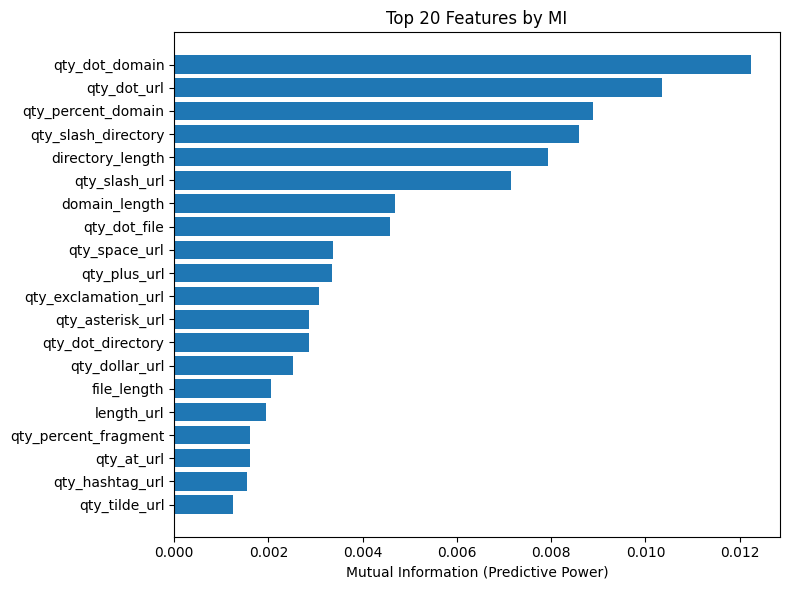

In [16]:
top_k = 20
top_mi = mi_df.head(top_k).sort_values("mutual_information")

plt.figure(figsize=(8, 6))
plt.barh(top_mi["feature"], top_mi["mutual_information"])
plt.xlabel("Mutual Information (Predictive Power)")
plt.title(f"Top {top_k} Features by MI")
plt.tight_layout()
plt.show()




--- Plotting http_status ---


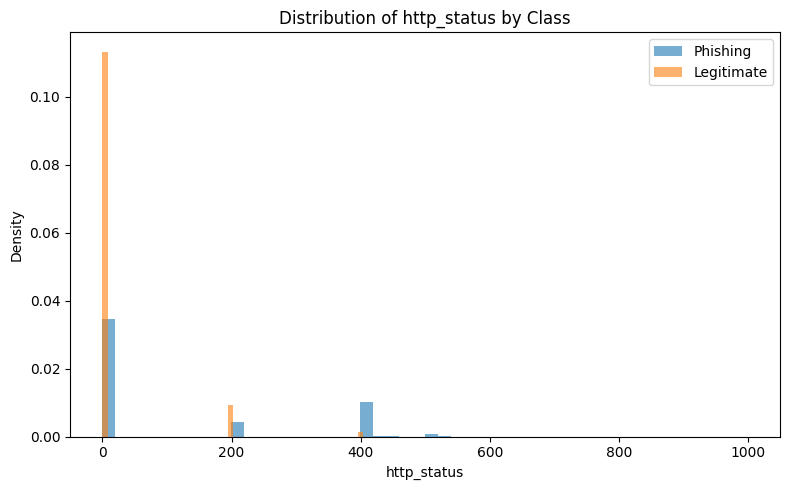


--- Plotting qty_dot_domain ---


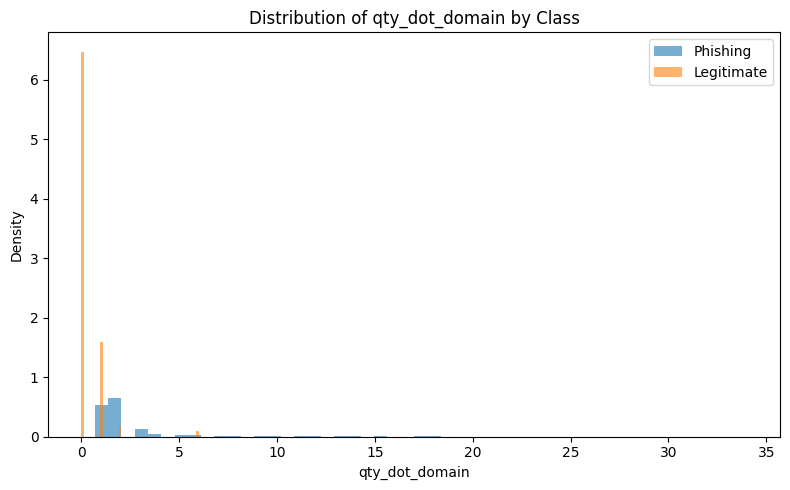


--- Plotting time_response ---


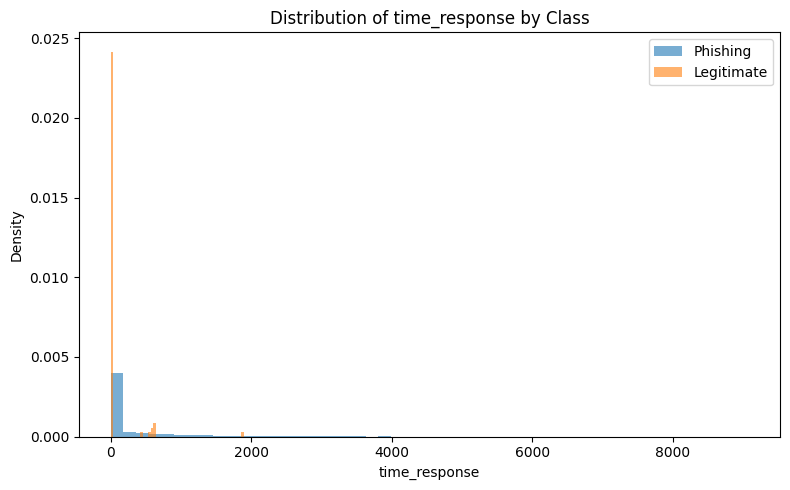


--- Plotting length_url ---


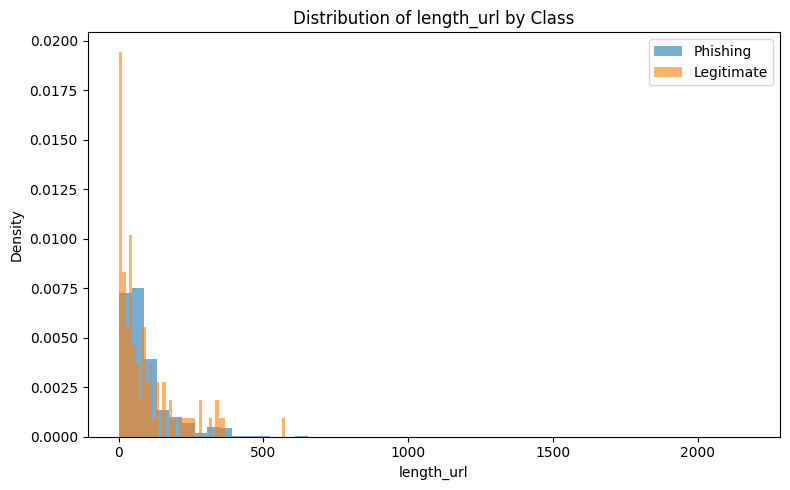


--- Plotting qty_redirects ---


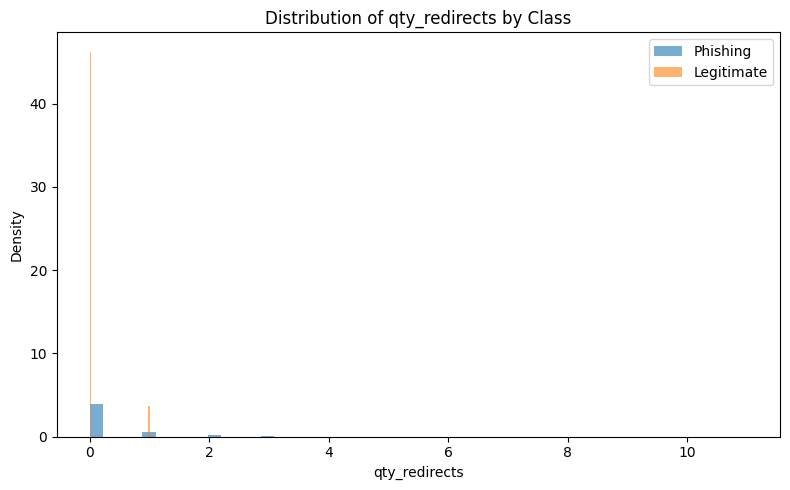


--- Plotting qty_slash_url ---


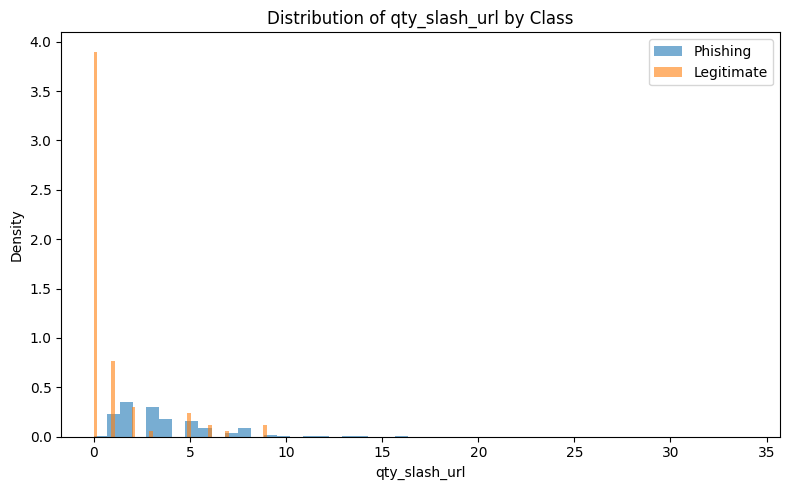


--- Plotting qty_dot_url ---


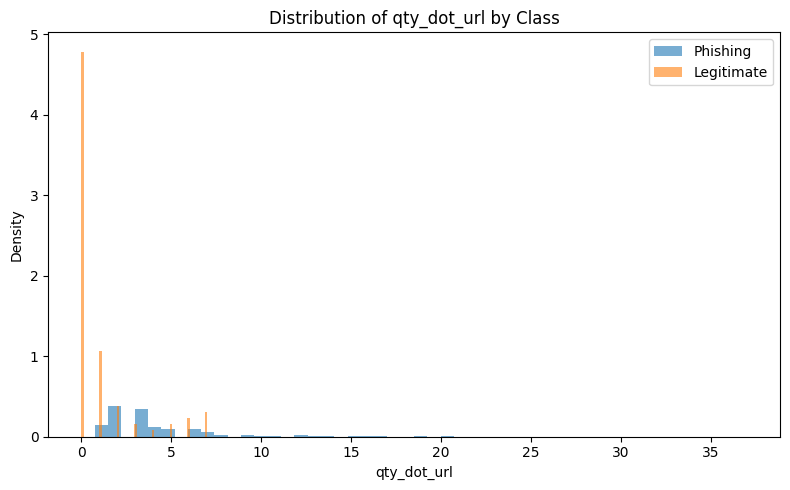


--- Plotting params_length ---


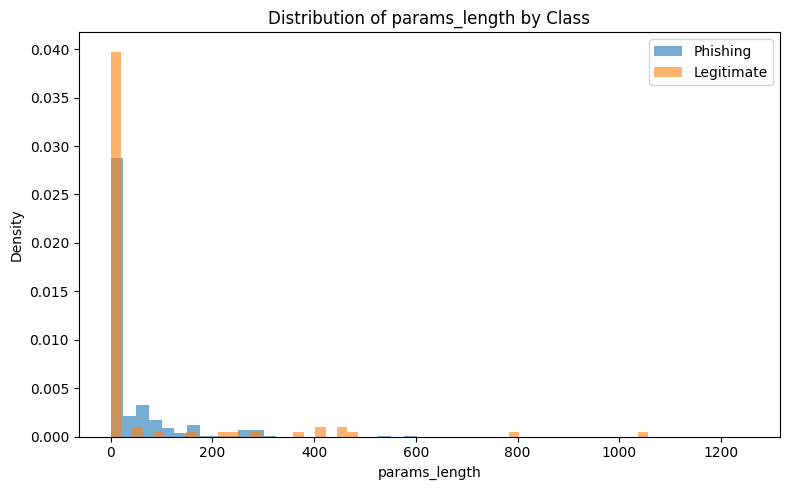


--- Plotting qty_slash_directory ---


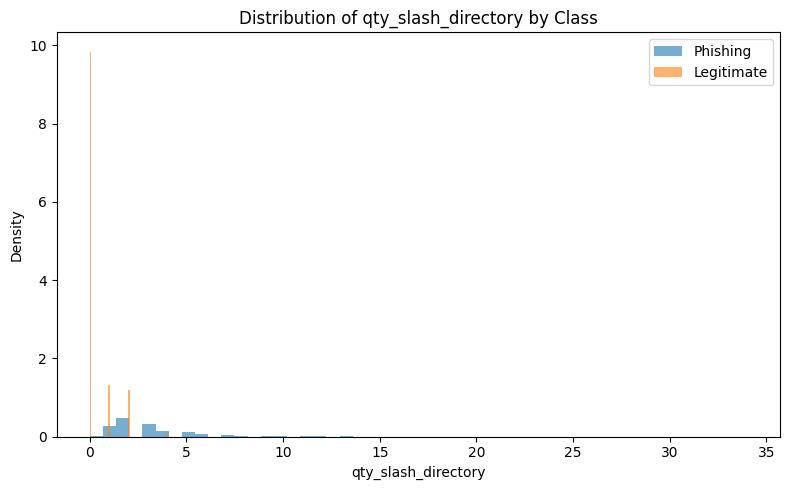


--- Plotting directory_length ---


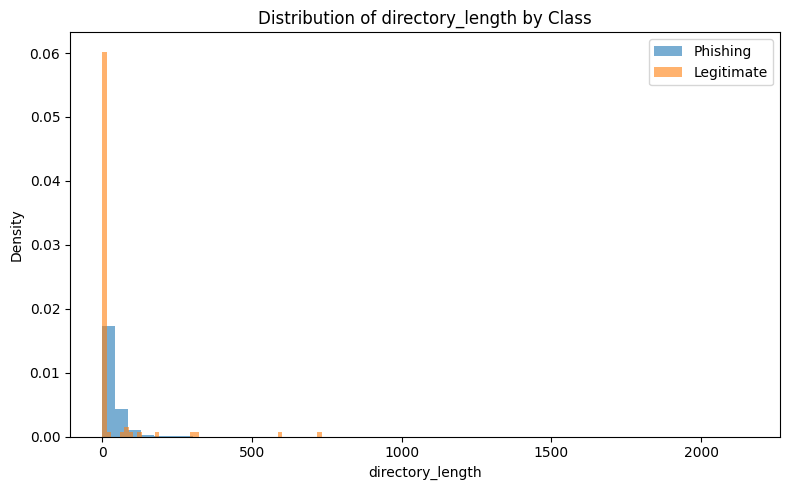


--- Plotting domain_length ---


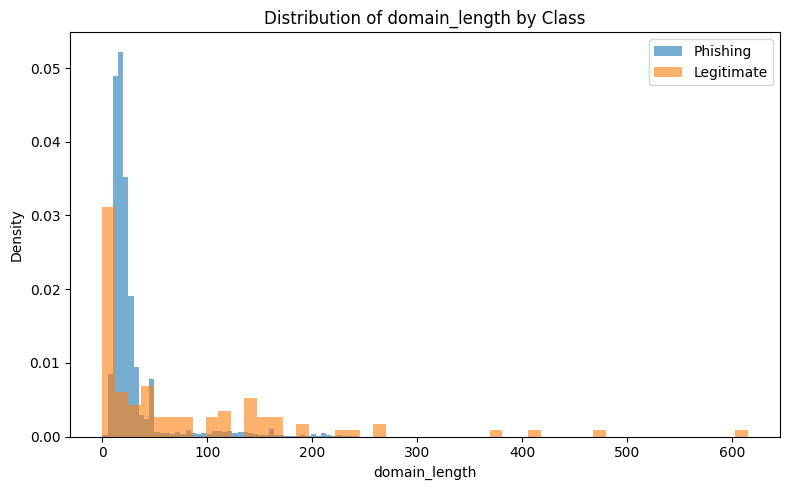


--- Plotting qty_equal_url ---


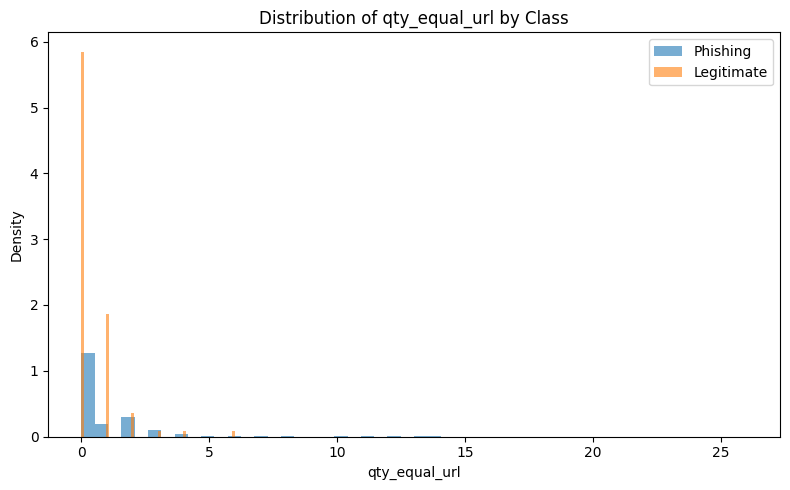


--- Plotting qty_questionmark_url ---


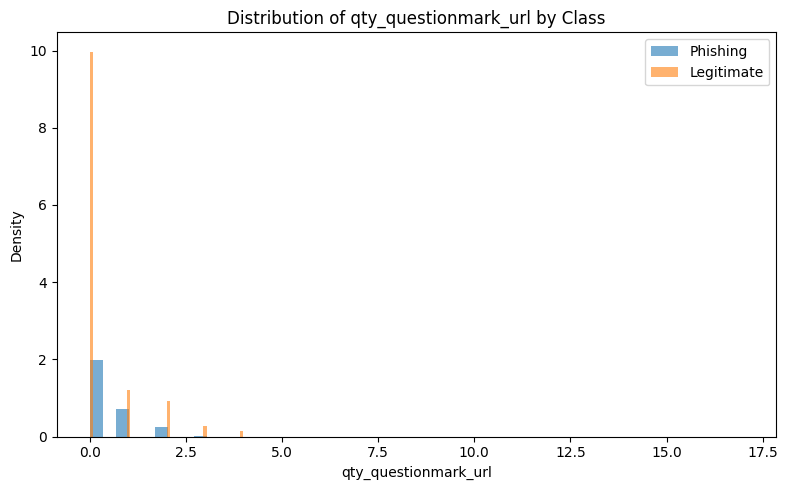


--- Plotting file_length ---


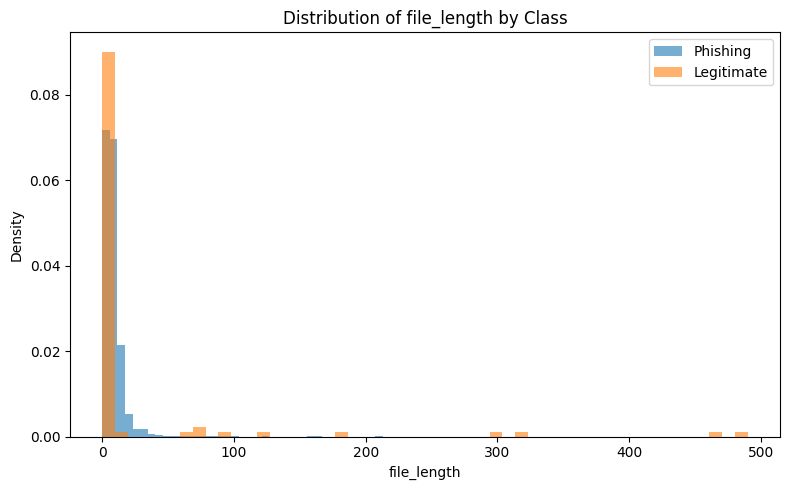


--- Plotting qty_dot_directory ---


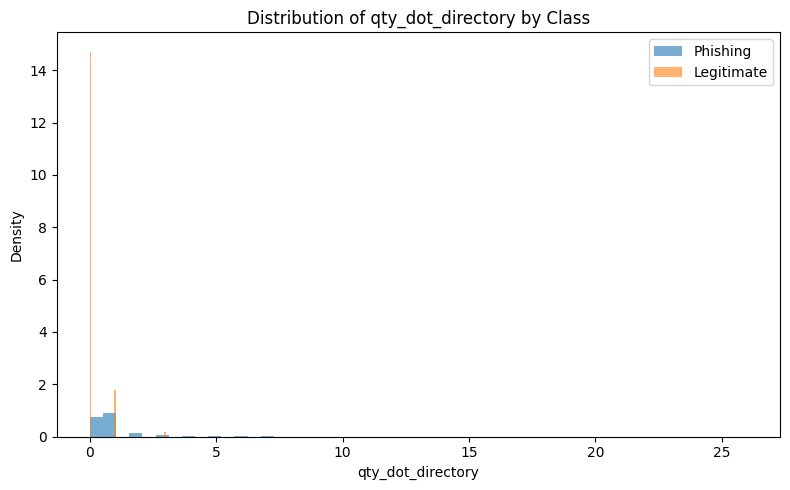


--- Plotting qty_equal_params ---


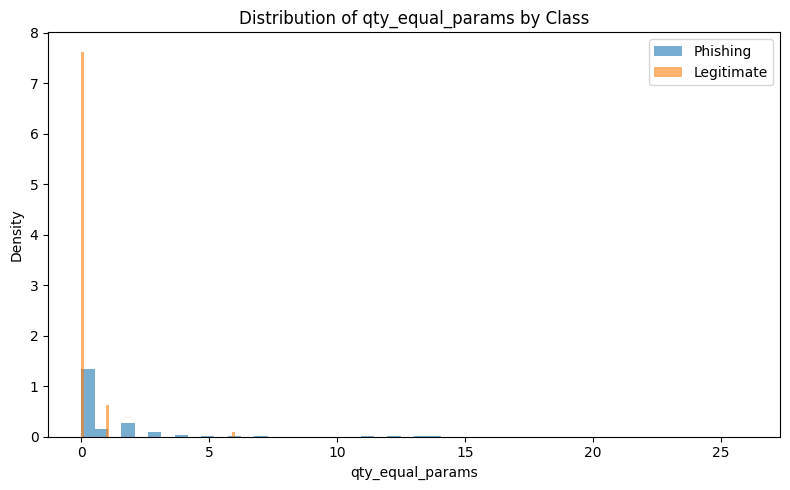


--- Plotting qty_and_url ---


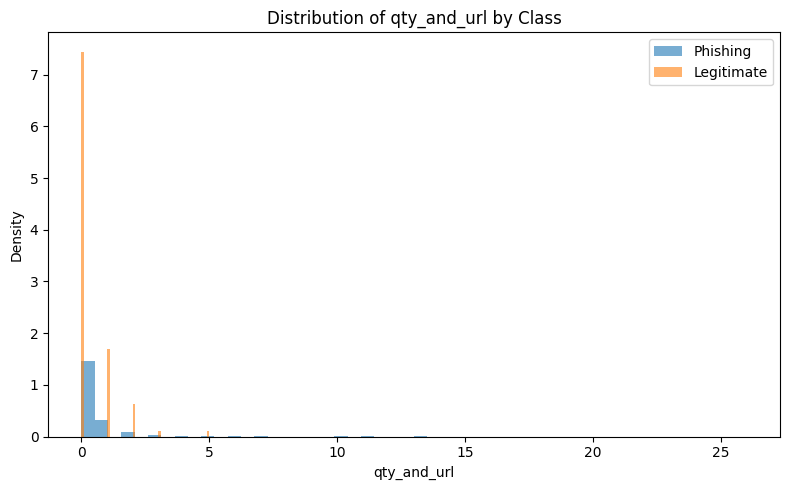


--- Plotting qty_and_params ---


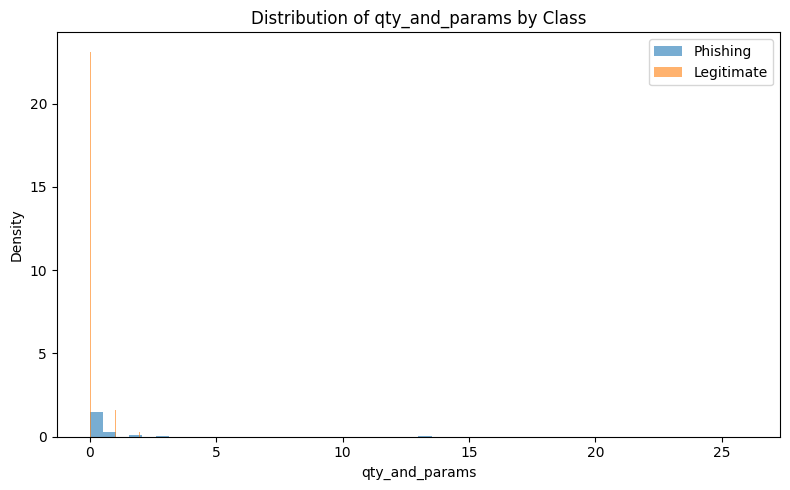


--- Plotting qty_dot_params ---


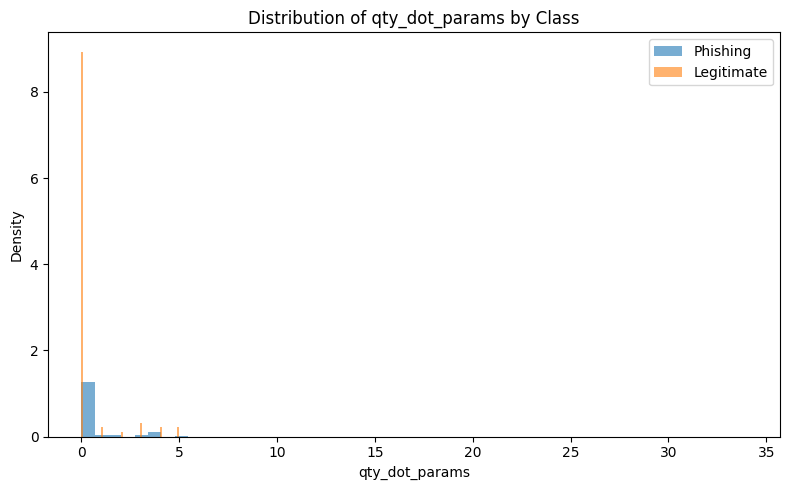


--- Plotting qty_hyphen_params ---


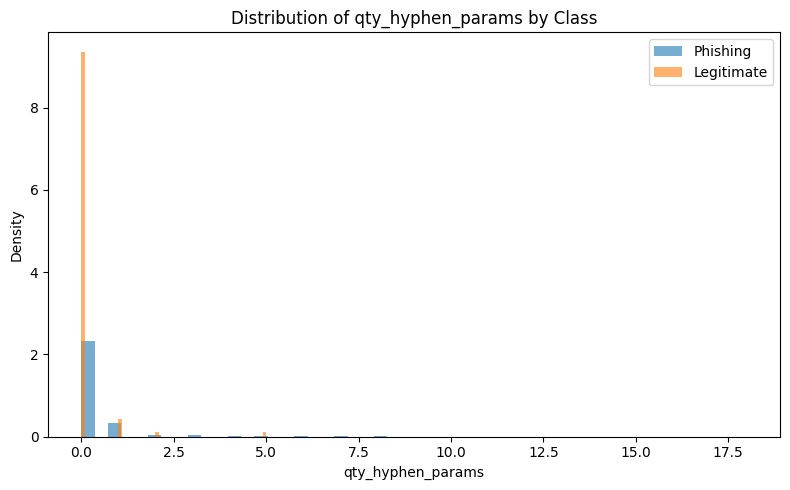

In [17]:
import matplotlib.pyplot as plt

top_features = [
    "http_status",
    "qty_dot_domain",
    "time_response",
    "length_url",
    "qty_redirects",
    "qty_slash_url",
    "qty_dot_url",
    "params_length",
    "qty_slash_directory",
    "directory_length",
    "domain_length",
    "qty_equal_url",
    "qty_questionmark_url",
    "file_length",
    "qty_dot_directory",
    "qty_equal_params",
    "qty_and_url",
    "qty_and_params",
    "qty_dot_params",
    "qty_hyphen_params"
]

def plot_feature_distribution(df, feature, target="Label", bins=50):
    phishing = df[df[target] == 1][feature]
    legit    = df[df[target] == 0][feature]

    plt.figure(figsize=(8, 5))
    plt.hist(phishing, bins=bins, alpha=0.6, label="Phishing", density=True)
    plt.hist(legit,    bins=bins, alpha=0.6, label="Legitimate", density=True)
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.title(f"Distribution of {feature} by Class")
    plt.legend()
    plt.tight_layout()
    plt.show()

for feat in top_features:
    if feat in sample_df.columns:
        print(f"\n--- Plotting {feat} ---")
        plot_feature_distribution(sample_df, feat, target="Label")


**Correlation heatmap + High Correlation Network**

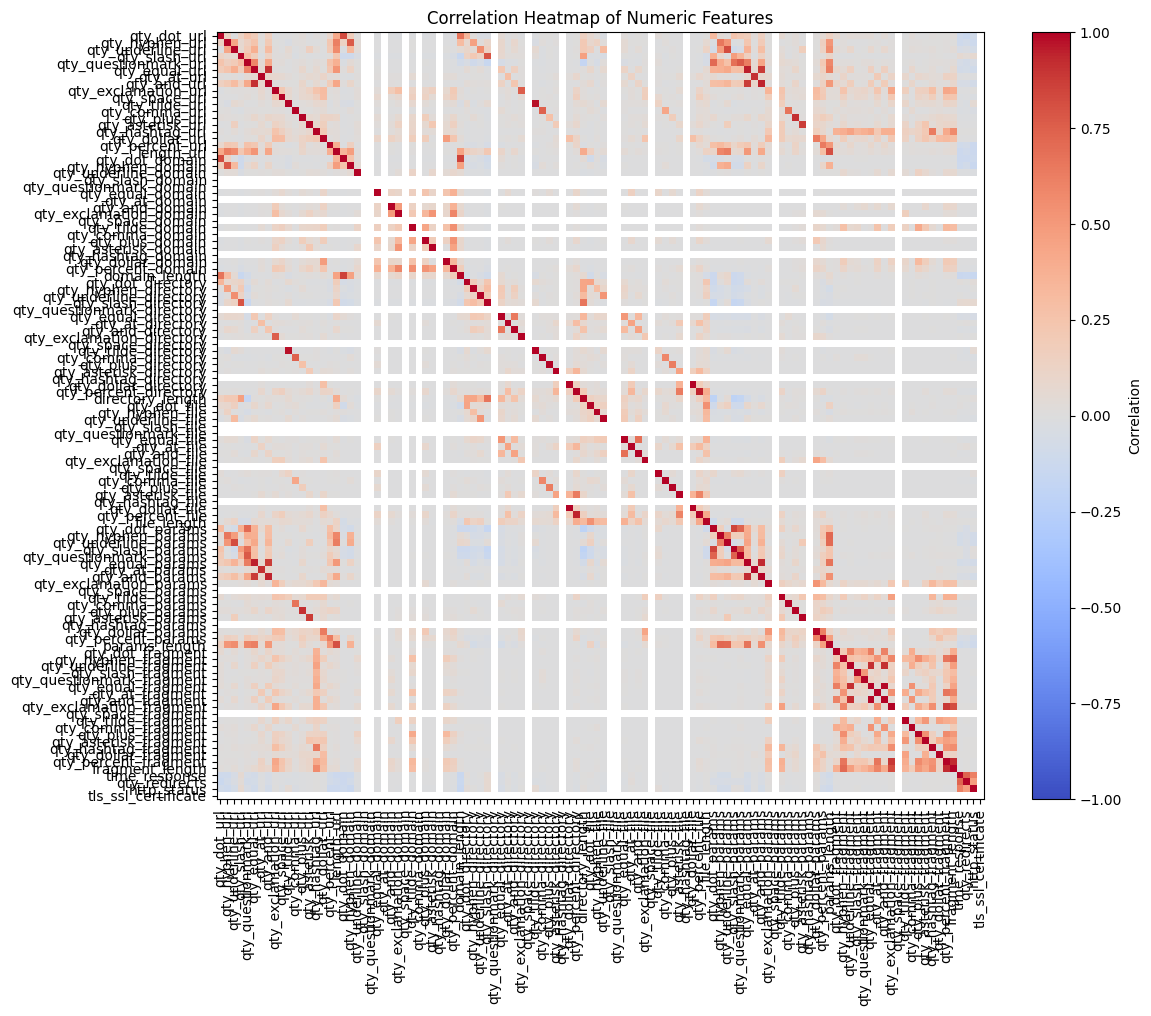


=== TOP CORRELATED FEATURE PAIRS (ABS > 0.8) ===
qty_and_fragment          qty_equal_fragment          0.990197
qty_equal_fragment        qty_and_fragment            0.990197
qty_tilde_url             qty_tilde_directory         0.973233
qty_tilde_directory       qty_tilde_url               0.973233
qty_equal_url             qty_equal_params            0.947125
qty_equal_params          qty_equal_url               0.947125
qty_percent_file          qty_percent_directory       0.944875
qty_percent_directory     qty_percent_file            0.944875
qty_and_params            qty_and_url                 0.944454
qty_and_url               qty_and_params              0.944454
fragment_length           qty_percent_fragment        0.928453
qty_percent_fragment      fragment_length             0.928453
qty_equal_params          qty_and_params              0.923567
qty_and_params            qty_equal_params            0.923567
qty_at_params             qty_at_url                  0.913805
qty_a

In [18]:
num_df = sample_df.select_dtypes(include=[np.number]).copy()
if "Label" in num_df.columns:
    num_df = num_df.drop(columns=["Label"])

corr = num_df.corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

# Top correlated pairs
corr_unstacked = corr.abs().unstack().sort_values(ascending=False)
corr_unstacked = corr_unstacked[corr_unstacked < 1.0]  # remove self correlation
print("\n=== TOP CORRELATED FEATURE PAIRS (ABS > 0.8) ===")
print(corr_unstacked[corr_unstacked > 0.8].head(30))


**Correlation Network (edges where |corr| > 0.75)**

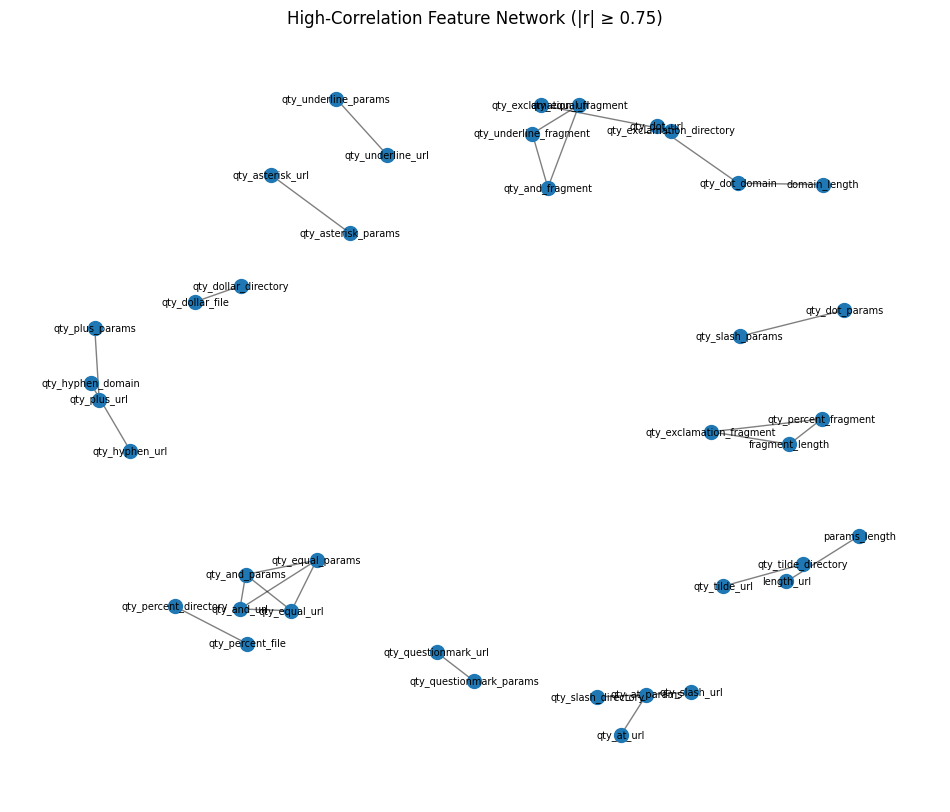

In [20]:
import networkx as nx
import matplotlib.pyplot as plt

threshold = 0.75
G = nx.Graph()

for i, col1 in enumerate(corr.columns):
    for j, col2 in enumerate(corr.columns):
        if j <= i:
            continue
        w = corr.iloc[i, j]
        if abs(w) >= threshold:
            G.add_edge(col1, col2, weight=abs(w))

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.4, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=100)
nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=7)
plt.title(f"High-Correlation Feature Network (|r| ≥ {threshold})")
plt.axis("off")
plt.show()

**Risk Curves – Phishing Rate vs Feature Quantiles**

/tmp/ipython-input-3607246702.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk = df_local.groupby("bin")[target].mean()
/tmp/ipython-input-3607246702.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count = df_local.groupby("bin")[target].count()



=== Phishing risk vs length_url (by quantile bins) ===
                 phishing_rate  count
bin                                  
(0.999, 27.0]         0.992989   4564
(27.0, 34.0]          0.999100   4444
(34.0, 43.0]          0.997810   4567
(43.0, 53.0]          0.999046   4195
(53.0, 66.0]          0.998667   4500
(66.0, 80.0]          0.999557   4513
(80.0, 98.0]          0.998635   4396
(98.0, 125.0]         0.998210   4470
(125.0, 197.0]        0.997931   4350
(197.0, 2175.0]       0.997061   4423


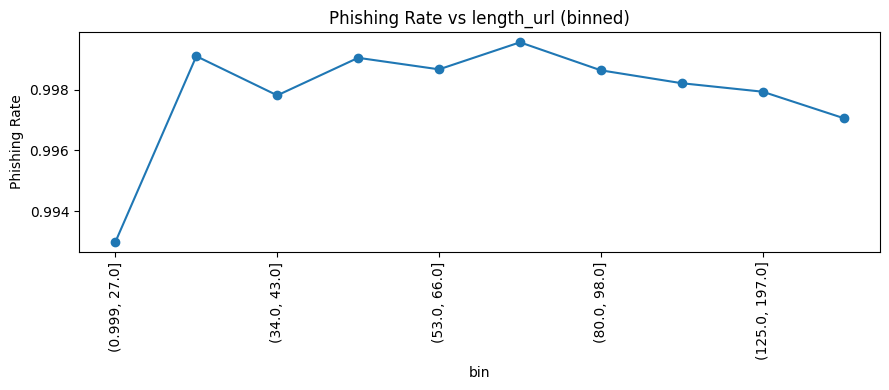


=== Phishing risk vs params_length (by quantile bins) ===
                 phishing_rate  count
bin                                  
(-0.001, 14.0]        0.997506  31271
(14.0, 64.0]          0.999326   4454
(64.0, 106.0]         0.999772   4388
(106.0, 1253.0]       0.997215   4309


/tmp/ipython-input-3607246702.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk = df_local.groupby("bin")[target].mean()
/tmp/ipython-input-3607246702.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count = df_local.groupby("bin")[target].count()


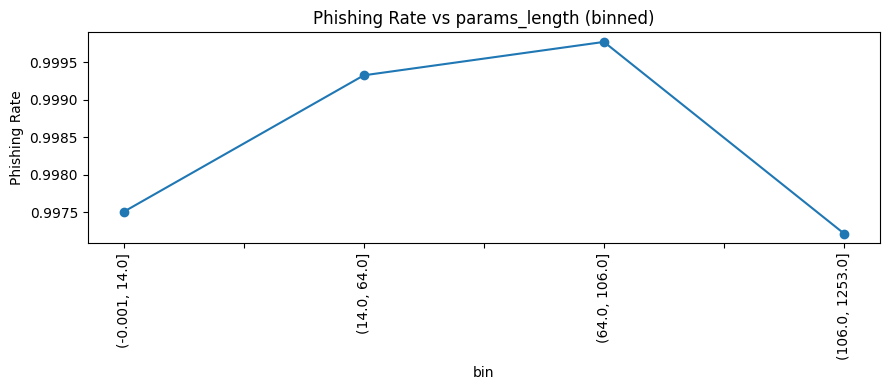

/tmp/ipython-input-3607246702.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk = df_local.groupby("bin")[target].mean()
/tmp/ipython-input-3607246702.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count = df_local.groupby("bin")[target].count()



=== Phishing risk vs domain_length (by quantile bins) ===
                phishing_rate  count
bin                                 
(-0.001, 11.0]       0.992608   4735
(11.0, 13.0]         0.999404   5033
(13.0, 15.0]         0.999633   5454
(15.0, 17.0]         0.999602   5027
(17.0, 18.0]         1.000000   2122
(18.0, 21.0]         0.999814   5384
(21.0, 24.0]         1.000000   4189
(24.0, 28.0]         0.999461   3712
(28.0, 45.0]         0.998474   5242
(45.0, 615.0]        0.988365   3524


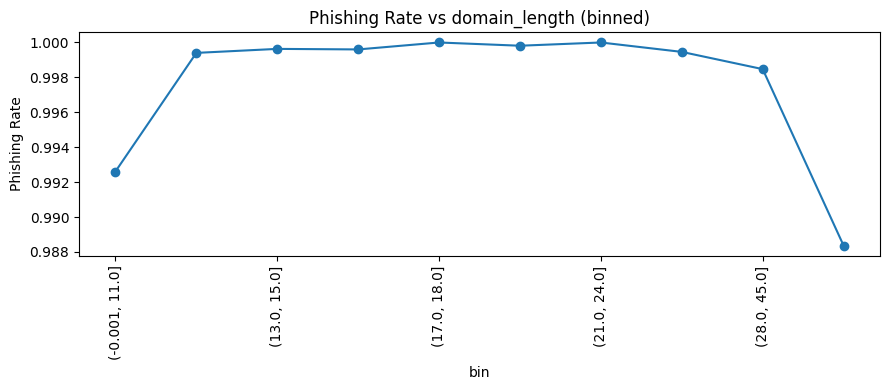


=== Phishing risk vs directory_length (by quantile bins) ===
                phishing_rate  count
bin                                 
(-0.001, 4.0]        0.987072   5724
(4.0, 8.0]           0.999158   3565
(8.0, 14.0]          0.998688   4574
(14.0, 20.0]         1.000000   5930
(20.0, 24.0]         0.999653   2879
(24.0, 31.0]         1.000000   4205
(31.0, 38.0]         1.000000   4421
(38.0, 50.0]         1.000000   4555
(50.0, 68.0]         0.999763   4226
(68.0, 2156.0]       0.997928   4343


/tmp/ipython-input-3607246702.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk = df_local.groupby("bin")[target].mean()
/tmp/ipython-input-3607246702.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count = df_local.groupby("bin")[target].count()


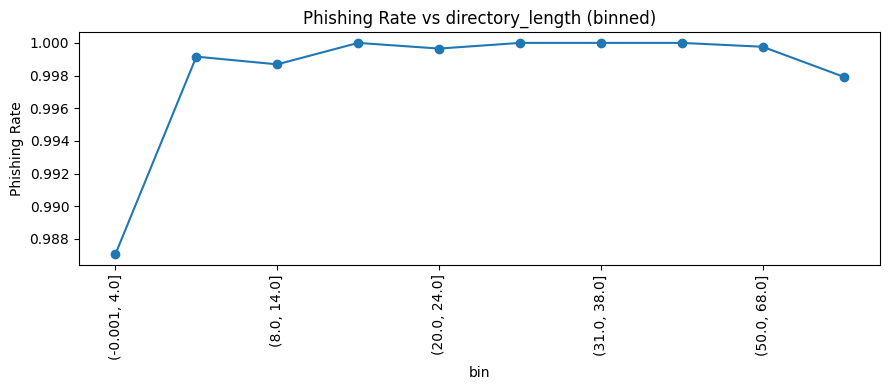

/tmp/ipython-input-3607246702.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk = df_local.groupby("bin")[target].mean()
/tmp/ipython-input-3607246702.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count = df_local.groupby("bin")[target].count()



=== Phishing risk vs time_response (by quantile bins) ===
                  phishing_rate  count
bin                                   
(-0.001, 81.0]         0.997234  31096
(81.0, 461.8]          0.999775   4441
(461.8, 1048.0]        0.998652   4451
(1048.0, 9075.0]       0.999774   4434


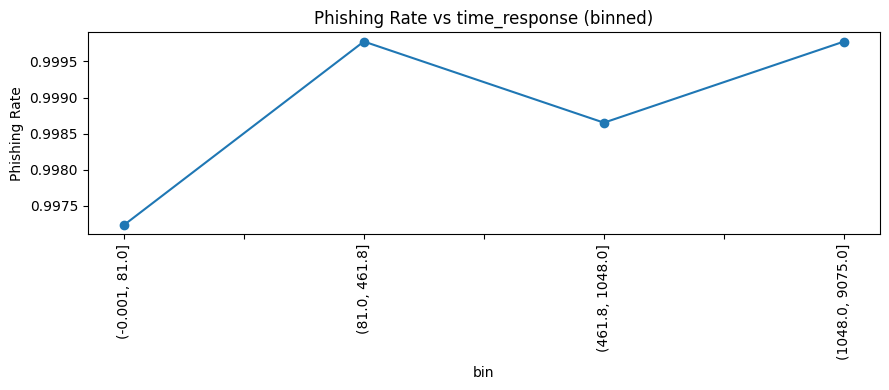

/tmp/ipython-input-3607246702.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk = df_local.groupby("bin")[target].mean()
/tmp/ipython-input-3607246702.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count = df_local.groupby("bin")[target].count()



=== Phishing risk vs qty_redirects (by quantile bins) ===
               phishing_rate  count
bin                                
(-0.001, 1.0]       0.997804  42796
(1.0, 11.0]         1.000000   1626


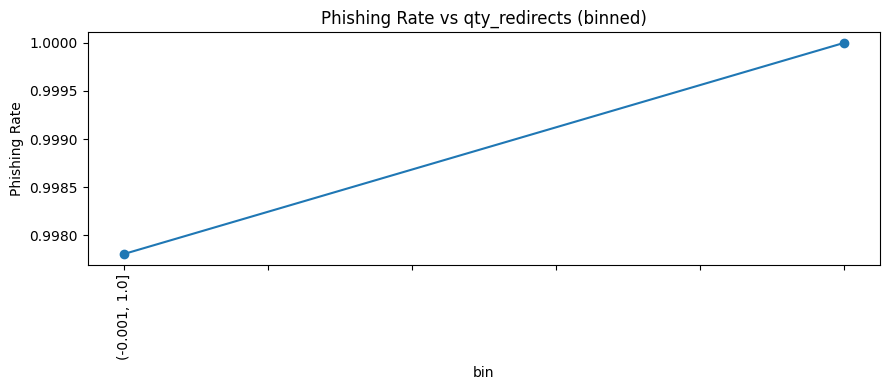

/tmp/ipython-input-3607246702.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk = df_local.groupby("bin")[target].mean()
/tmp/ipython-input-3607246702.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count = df_local.groupby("bin")[target].count()



=== Phishing risk vs qty_dot_domain (by quantile bins) ===
               phishing_rate  count
bin                                
(-0.001, 1.0]       0.994277  15900
(1.0, 2.0]          0.999897  19344
(2.0, 3.0]          1.000000   3655
(3.0, 4.0]          1.000000   1098
(4.0, 34.0]         0.999774   4425


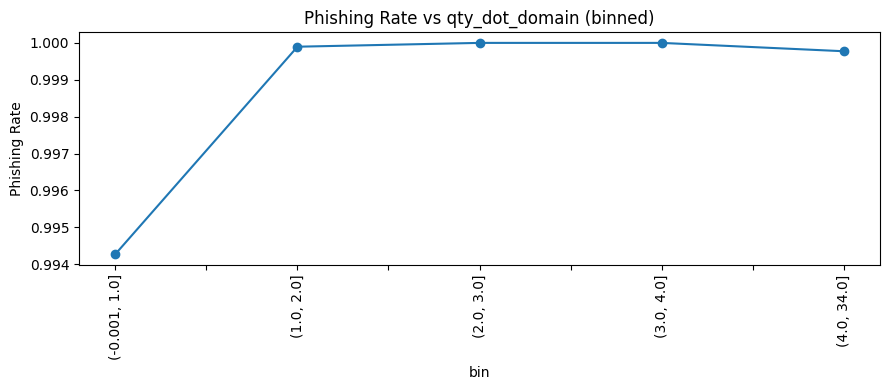

/tmp/ipython-input-3607246702.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk = df_local.groupby("bin")[target].mean()
/tmp/ipython-input-3607246702.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count = df_local.groupby("bin")[target].count()



=== Phishing risk vs http_status (by quantile bins) ===
                 phishing_rate  count
bin                                  
(-0.001, 200.0]       0.997306  34522
(200.0, 403.0]        1.000000   1231
(403.0, 404.0]        0.999846   6508
(404.0, 999.0]        1.000000   2161


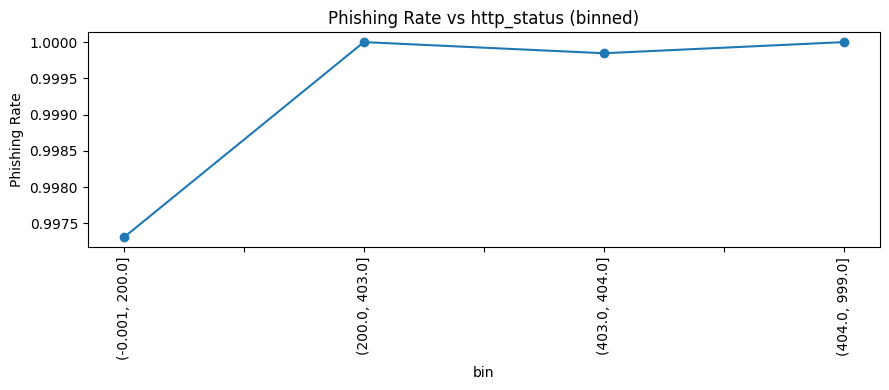

In [21]:
def risk_curve(df, feature, n_bins=10, target="Label"):
    df_local = df[[feature, target]].dropna().copy()
    df_local["bin"] = pd.qcut(df_local[feature], q=n_bins, duplicates="drop")
    risk = df_local.groupby("bin")[target].mean()
    count = df_local.groupby("bin")[target].count()

    print(f"\n=== Phishing risk vs {feature} (by quantile bins) ===")
    print(pd.DataFrame({"phishing_rate": risk, "count": count}))

    plt.figure(figsize=(9, 4))
    risk.plot(marker="o")
    plt.xticks(rotation=90)
    plt.ylabel("Phishing Rate")
    plt.title(f"Phishing Rate vs {feature} (binned)")
    plt.tight_layout()
    plt.show()

# Choose key features from your MI ranking:
risk_features = [
    "length_url",
    "params_length",
    "domain_length",
    "directory_length",
    "time_response",
    "qty_redirects",
    "qty_dot_domain",
    "http_status"
]

for feat in risk_features:
    if feat in sample_df.columns:
        risk_curve(sample_df, feat)


**Box/Violin-style Feature Comparisons by Class**

/tmp/ipython-input-4088790721.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["Legit (0)", "Phish (1)"])


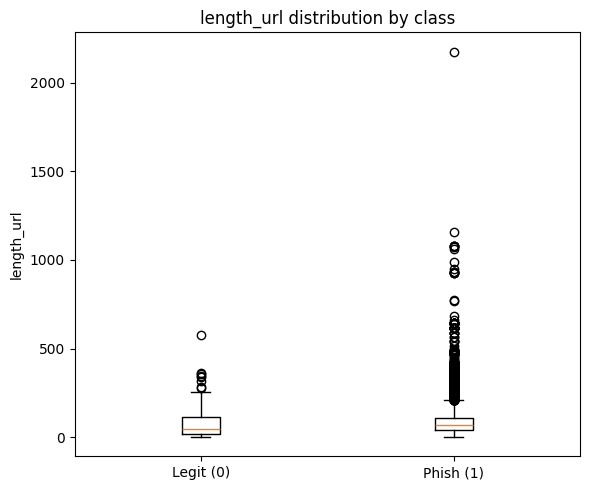

/tmp/ipython-input-4088790721.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["Legit (0)", "Phish (1)"])


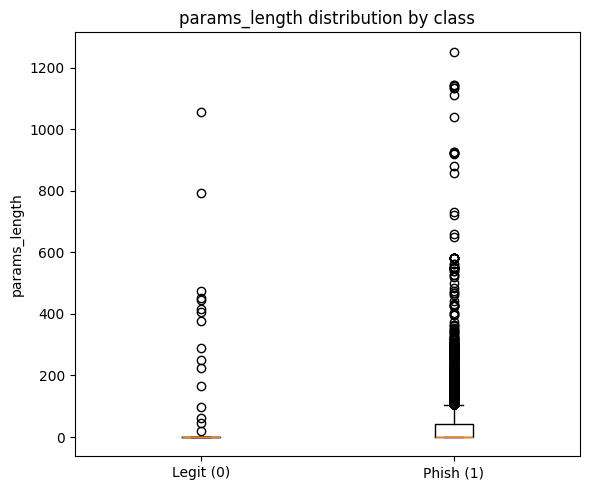

/tmp/ipython-input-4088790721.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["Legit (0)", "Phish (1)"])


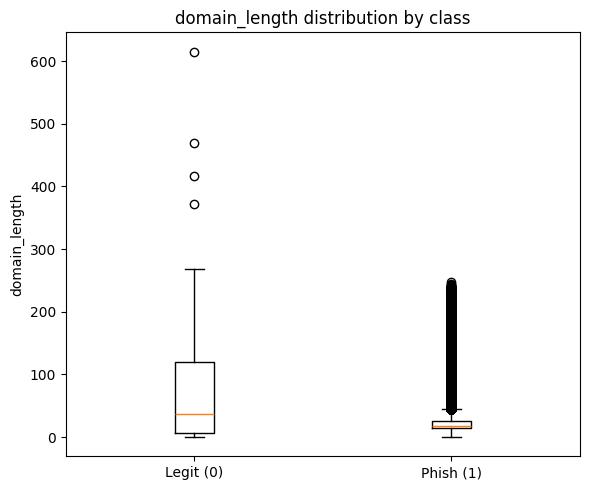

/tmp/ipython-input-4088790721.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["Legit (0)", "Phish (1)"])


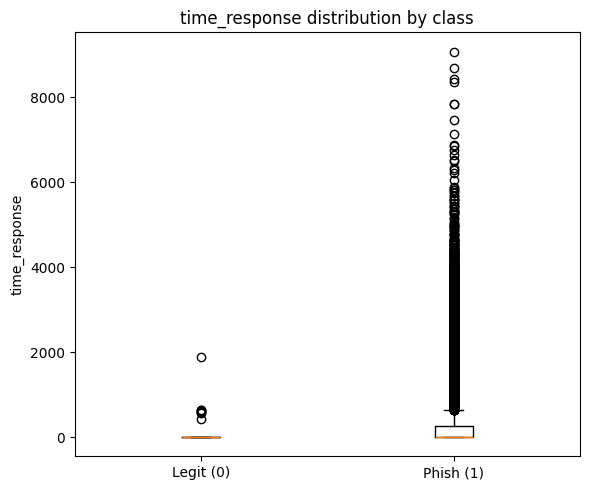

In [22]:
def boxplot_by_label(df, feature, target="Label"):
    plt.figure(figsize=(6, 5))
    data0 = df[df[target] == 0][feature]
    data1 = df[df[target] == 1][feature]

    plt.boxplot([data0, data1], labels=["Legit (0)", "Phish (1)"])
    plt.ylabel(feature)
    plt.title(f"{feature} distribution by class")
    plt.tight_layout()
    plt.show()

for feat in ["length_url", "params_length", "domain_length", "time_response"]:
    if feat in sample_df.columns:
        boxplot_by_label(sample_df, feat)


In [24]:
import scipy.stats as ss

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    phi2corr = max(0, phi2 - (k-1)*(r-1)/(n-1))
    rcorr = r - (r-1)**2/(n-1)
    kcorr = k - (k-1)**2/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

if "server_header" in sample_df.columns:
    print("\n=== Cramér's V (server_header vs Label) ===")
    val = cramers_v(sample_df["server_header"], sample_df["Label"])
    print("Cramér's V:", val)


=== Cramér's V (server_header vs Label) ===
Cramér's V: 0.0


In [25]:
if "server_header" in sample_df.columns:
    print("\n=== Server header distribution by class (top 10) ===")
    print(sample_df.groupby("server_header")["Label"].mean().sort_values(ascending=False).head(10))



=== Server header distribution by class (top 10) ===
server_header
wts/1.7.4                    1.0
*********                    1.0
.V03 Apache/1.3.42 (Unix)    1.0
519                          1.0
ATS                          1.0
AkamaiGHost                  1.0
AliyunOSS                    1.0
AmazonS3                     1.0
Apache                       1.0
Apache / ZoneOS              1.0
Name: Label, dtype: float64


**PCA visualization**

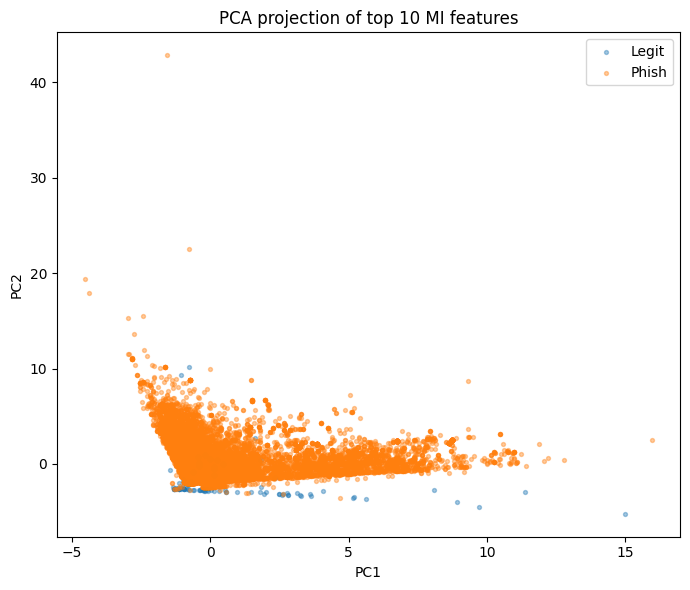

Explained variance ratios: [0.26025608 0.23039709]


In [27]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Select top 10 MI features
top10_feats = mi_df.head(10)["feature"].tolist()
X_top10 = sample_df[top10_feats].copy().dropna()
y_top10 = sample_df.loc[X_top10.index, "Label"]

# Standardize (roughly) – subtract mean, divide by std
X_std = (X_top10 - X_top10.mean()) / (X_top10.std() + 1e-9)

pca = PCA(n_components=2, random_state=42)
proj = pca.fit_transform(X_std)

plt.figure(figsize=(7, 6))
plt.scatter(proj[y_top10==0, 0], proj[y_top10==0, 1], alpha=0.4, label="Legit", s=8)
plt.scatter(proj[y_top10==1, 0], proj[y_top10==1, 1], alpha=0.4, label="Phish", s=8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of top 10 MI features")
plt.legend()
plt.tight_layout()
plt.show()

print("Explained variance ratios:", pca.explained_variance_ratio_)

**MI stability across random subsamples**

In [28]:
def compute_mi_for_subset(df, features=None, frac=0.3, random_state=42):
    df_sub = df.sample(frac=frac, random_state=random_state)
    X_sub = df_sub.drop(columns=[c for c in ["url", "server_header"] if c in df_sub.columns] + ["Label"])
    y_sub = df_sub["Label"]

    non_numeric = X_sub.select_dtypes(include=["object", "category"]).columns
    if len(non_numeric) > 0:
        enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        X_sub[non_numeric] = enc.fit_transform(X_sub[non_numeric])

    mi_sub = mutual_info_classif(X_sub, y_sub, random_state=random_state)
    mi_sub_df = pd.DataFrame({"feature": X_sub.columns, "mi": mi_sub}).sort_values("mi", ascending=False)
    if features is not None:
        mi_sub_df = mi_sub_df[mi_sub_df["feature"].isin(features)]
    return mi_sub_df

# Track MI for your previously top 10 features across 5 random subsamples
top10 = mi_df.head(10)["feature"].tolist()
stability_results = []

for seed in range(5):
    sub_mi_df = compute_mi_for_subset(sample_df, features=top10, frac=0.3, random_state=seed)
    sub_mi_df["seed"] = seed
    stability_results.append(sub_mi_df)

stability_df = pd.concat(stability_results)
print("\n=== MI stability for top 10 features across subsamples ===")
print(stability_df.pivot(index="feature", columns="seed", values="mi"))



=== MI stability for top 10 features across subsamples ===
seed                        0         1         2         3         4
feature                                                              
directory_length     0.006906  0.008165  0.007223  0.005350  0.009354
domain_length        0.003228  0.003256  0.004863  0.002544  0.003302
qty_dot_domain       0.010030  0.010364  0.010890  0.009482  0.014765
qty_dot_file         0.002280  0.002032  0.002622  0.001452  0.002855
qty_dot_url          0.009656  0.010164  0.010361  0.007151  0.013093
qty_percent_domain   0.009174  0.006475  0.008238  0.004074  0.010214
qty_plus_url         0.003081  0.003158  0.003385  0.000675  0.004565
qty_slash_directory  0.007965  0.008262  0.007637  0.005528  0.010383
qty_slash_url        0.007182  0.007774  0.006817  0.005140  0.008747
qty_space_url        0.002127  0.003203  0.004116  0.000573  0.004861


In [30]:
import pandas as pd

# Load dataset (already bool)
sample_df = pd.read_csv("final_features_cleaned_dataset.csv", low_memory=False)
sample_df['Label'] = sample_df['Label'].astype(bool)

# Count True/False
counts = sample_df['Label'].value_counts()
percentages = (counts / counts.sum()) * 100

# Display neatly
print("=== Label Distribution ===")
for label, count in counts.items():
    meaning = "Phishing" if label else "Legitimate"
    print(f"{meaning} ({label}): {count:,} URLs ({percentages[label]:.2f}%)")

=== Label Distribution ===
Legitimate (False): 1,350,500 URLs (89.83%)
Phishing (True): 152,846 URLs (10.17%)
